In [11]:
import os
import sys
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

device = 'cuda' if torch.cuda.is_available() else 'cpu'
project_dir = os.path.dirname(os.getcwd())
sys.path.append(project_dir)

from utils.plots import plot_training_metrics
from utils.train import evaluate_model
from utils.summary import get_model_stats
from utils.losses import Accuracy, MIoU, MulticlassF1Score, PrecisionRecallF1

# Helper Funcs

In [22]:
def get_predictions(model, dataloader, device='cpu'):
    model.to(device)
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)  # ✅ Assign back to variable
            lbls = lbls.to(device)      # ✅ Assign back to variable
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            labels.extend(lbls.cpu().numpy())
    return np.array(preds), np.array(labels)


# MNIST

In [2]:
from data.mnist import get_mnist_pipeline
import models.baseline as mlp

_, _, test_loader = get_mnist_pipeline(batch_size=128, val_split=0)
sample_x, sample_y = next(iter(test_loader))

# can plot some images
def show_images():
    pass

In [ ]:
teacher = mlp.mnist1200().to(device)
smaller = mlp.mnist800().to(device)
student = mlp.mnist800().to(device)
trnsfr1 = mlp.mnist800().to(device)
trnsfr2 = mlp.mnist800().to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("MNIST1200 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("MNIST800 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

teacher_path = '../models/final_weights/mnist_teacher.pth'
smaller_path = '../models/final_weights/mnist_smaller.pth'
student_path = '../models/final_weights/mnist_student_t5.pth'
trnsfr1_path = '../models/final_weights/mnist_transfer_t3_a70_0.pth'
trnsfr2_path = '../models/final_weights/mnist_reference.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
trnsfr1_state = torch.load(trnsfr1_path, map_location=device)
trnsfr2_state = torch.load(trnsfr2_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])
trnsfr1.load_state_dict(trnsfr1_state['state_dict'])
trnsfr2.load_state_dict(trnsfr2_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
smaller_test_acc = evaluate_model(test_loader, smaller, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
trnsfr1_test_acc = evaluate_model(test_loader, trnsfr1, Accuracy(), device)
trnsfr2_test_acc = evaluate_model(test_loader, trnsfr2, Accuracy(), device)

print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Smaller: Val Accuracy: {smaller_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")
print(f"trnsfr1: Val Accuracy: {trnsfr1_state['accuracy']:.4f}")
print(f"trnsfr2: Val Accuracy: {trnsfr2_state['accuracy']:.4f}")

print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Smaller: Test Accuracy: {smaller_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")
print(f"trnsfr1: Test Accuracy: {trnsfr1_test_acc:.4f}")
print(f"trnsfr2: Test Accuracy: {trnsfr2_test_acc:.4f}")

MNIST1200 stats:
flops: 490598400
params: 3836410
MNIST800 stats:
flops: 245145600
params: 1917610
evaluating...: 100%|██████████| 79/79 [00:02<00:00, 32.43it/s]
Teacher: Val Accuracy: 0.9908
Smaller: Val Accuracy: 0.9873
Student: Val Accuracy: 0.9886
trnsfr1: Val Accuracy: 0.9906
trnsfr2: Val Accuracy: 0.9911
Teacher: Test Accuracy: 0.9908
Smaller: Test Accuracy: 0.9873
Student: Test Accuracy: 0.9886
trnsfr1: Test Accuracy: 0.9725
trnsfr2: Test Accuracy: 0.8935


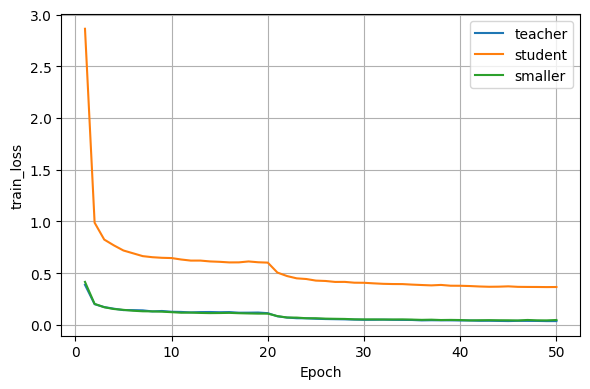

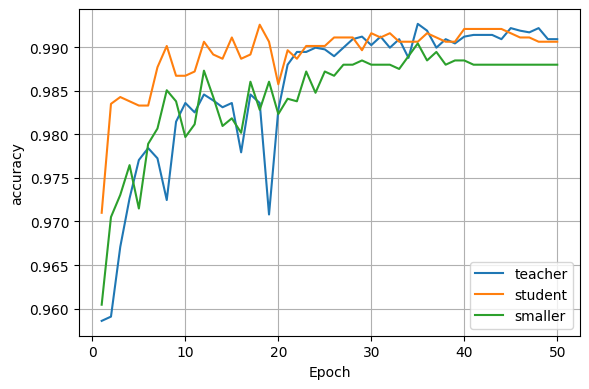

In [9]:
import os
import json
import matplotlib.pyplot as plt

project_dir = '..'  # Replace with your actual project directory

models = ['teacher', 'student', 'smaller']
collection = []
with open(os.path.join(project_dir, 'data/states/mnist_teacher.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_student_t5.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_smaller.json'), 'r') as f:
    collection.append(json.load(f))

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

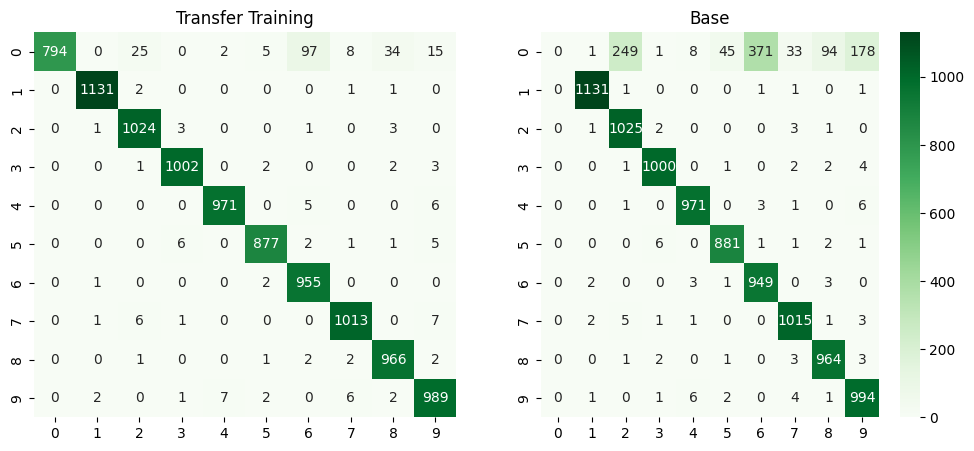

In [34]:
# Get predictions for both models
preds_transfer, labels = get_predictions(trnsfr1, test_loader, device)
preds_original, _ = get_predictions(trnsfr2, test_loader, device)

# Compute confusion matrices
cm_transfer = confusion_matrix(labels, preds_transfer)
cm_original = confusion_matrix(labels, preds_original)

# Compute min/max values for consistent color scaling
vmin = min(cm_transfer.min(), cm_original.min())
vmax = max(cm_transfer.max(), cm_original.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 1]})  # Same width ratio

# Left heatmap (No color bar)
sns.heatmap(cm_transfer, annot=True, fmt="d", cmap="Greens", ax=axes[0], vmin=vmin, vmax=vmax, cbar=False)
axes[0].set_title("Transfer Training")

# Right heatmap (With color bar)
sns.heatmap(cm_original, annot=True, fmt="d", cmap="Greens", ax=axes[1], vmin=vmin, vmax=vmax, cbar=True)
axes[1].set_title("Base")

plt.show()

In [35]:
del teacher
del smaller
del student
del trnsfr1
del trnsfr2

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

CUDA cache emptied.


# CIFAR

In [ ]:
from data.mnist import get_mnist_pipeline
import models.baseline as mlp

_, _, test_loader = get_mnist_pipeline(batch_size=128, val_split=0)
sample_x, sample_y = next(iter(test_loader))

# can plot some images
def show_images():
    pass

In [ ]:
from utils.train import evaluate_model
from utils.losses import Accuracy

student_path = '../models/final_weights/cifar10_resnet50_a20.pth'
teacher_path = '../models/final_weights/cifar10_resnet50_larger.pth'
smaller_path = '../models/final_weights/cifar10_resnet50_student.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Smaller: Val Accuracy: {smaller_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")

teacher = mlp.mnist1200().to(device)
smaller = mlp.mnist800().to(device)
student = mlp.mnist800().to(device)
teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
smaller_test_acc = evaluate_model(test_loader, smaller, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Smaller: Test Accuracy: {smaller_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")

#############

teacher = mlp.mnist1200().to(device)
smaller = mlp.mnist800().to(device)
student = mlp.mnist800().to(device)
trnsfr1 = mlp.mnist800().to(device)
trnsfr2 = mlp.mnist800().to(device)

sample = sample_x.to(device)
with torch.no_grad():
    print("MNIST1200 stats:")
    for name, param in get_model_stats(teacher, sample.shape).items():
        print(f"{name}: {param}")
    print("MNIST800 stats:")
    for name, param in get_model_stats(student, sample.shape).items():
        print(f"{name}: {param}")

teacher_path = '../models/final_weights/mnist_teacher.pth'
smaller_path = '../models/final_weights/mnist_smaller.pth'
student_path = '../models/final_weights/mnist_student_t5.pth'
trnsfr1_path = '../models/final_weights/mnist_transfer_t3_a70_0.pth'
trnsfr2_path = '../models/final_weights/mnist_reference.pth'

teacher_state = torch.load(teacher_path, map_location=device)
smaller_state = torch.load(smaller_path, map_location=device)
student_state = torch.load(student_path, map_location=device)
trnsfr1_state = torch.load(trnsfr1_path, map_location=device)
trnsfr2_state = torch.load(trnsfr2_path, map_location=device)

teacher.load_state_dict(teacher_state['state_dict'])
smaller.load_state_dict(smaller_state['state_dict'])
student.load_state_dict(student_state['state_dict'])
trnsfr1.load_state_dict(trnsfr1_state['state_dict'])
trnsfr2.load_state_dict(trnsfr2_state['state_dict'])

teacher_test_acc = evaluate_model(test_loader, teacher, Accuracy(), device)
smaller_test_acc = evaluate_model(test_loader, smaller, Accuracy(), device)
student_test_acc = evaluate_model(test_loader, student, Accuracy(), device)
trnsfr1_test_acc = evaluate_model(test_loader, trnsfr1, Accuracy(), device)
trnsfr2_test_acc = evaluate_model(test_loader, trnsfr2, Accuracy(), device)

print(f"Teacher: Val Accuracy: {teacher_state['accuracy']:.4f}")
print(f"Smaller: Val Accuracy: {smaller_state['accuracy']:.4f}")
print(f"Student: Val Accuracy: {student_state['accuracy']:.4f}")
print(f"trnsfr1: Val Accuracy: {trnsfr1_state['accuracy']:.4f}")
print(f"trnsfr2: Val Accuracy: {trnsfr2_state['accuracy']:.4f}")

print(f"Teacher: Test Accuracy: {teacher_test_acc:.4f}")
print(f"Smaller: Test Accuracy: {smaller_test_acc:.4f}")
print(f"Student: Test Accuracy: {student_test_acc:.4f}")
print(f"trnsfr1: Test Accuracy: {trnsfr1_test_acc:.4f}")
print(f"trnsfr2: Test Accuracy: {trnsfr2_test_acc:.4f}")

In [ ]:
import os
import json
import matplotlib.pyplot as plt

project_dir = '..'  # Replace with your actual project directory

models = ['teacher', 'student', 'smaller']
collection = []
with open(os.path.join(project_dir, 'data/states/mnist_teacher.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_student_t5.json'), 'r') as f:
    collection.append(json.load(f))
with open(os.path.join(project_dir, 'data/states/mnist_smaller.json'), 'r') as f:
    collection.append(json.load(f))

num_metrics = len(collection[0])
epochs = range(1, len(next(iter(collection[0].values()))) + 1)

for i, k in enumerate(collection[0].keys()):
    plt.figure(figsize=(6, 4))
    for j in range(len(collection)):
        plt.plot(epochs, collection[j][k], label=f"{models[j]}")
    plt.xlabel("Epoch")
    plt.ylabel(k)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [ ]:
del teacher
del smaller
del student
del trnsfr1
del trnsfr2

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("CUDA cache emptied.")

# VOC

In [ ]:
# voc